## Cell 1 — Introduction: Autonomous Mexico City Approach Control

## From controlling one machine to governing a dynamic system

This notebook is a pedagogical experiment in autonomous systems. It does **not** reproduce real Mexican air-traffic-control procedures, separation minima, routes, runway rules, or operational priorities, and it must not be interpreted as an aviation tool. Instead, it creates a deliberately synthetic world in which we can study a harder systems question: how does an autonomous architecture coordinate many interacting agents when the environment changes, forecasts are imperfect, decisions are constrained, and no single component is allowed to exercise unchecked authority?

The simulated world contains sixty IFR aircraft distributed across three airports: MEX, NLU, and TOL. The traffic mix is heterogeneous. Passenger, cargo, regional, wide-body, and military aircraft do not all have the same synthetic performance. Arrivals and departures coexist. Weather cells can appear, move, intensify, and disappear. Wind changes can alter synthetic runway modes. Some aircraft become concentrated around the same airport while others are already leaving the terminal area. The controller therefore faces a moving allocation problem rather than a static optimization problem.

The central lesson is that **autonomy is an architecture, not a model call**. A large language model can contribute judgment, but judgment is only one part of an intelligent control system. The complete loop used here is:

**World → Perception → Prediction → System Analysis → Context Construction → Judgment → Harness / Validation → Execution → Physical Dynamics → Feedback → Updated World**

Each stage solves a different problem. The world model defines what exists. Perception turns the evolving world into an observable state. Prediction asks what may happen next. System analysis identifies congestion and interaction effects that are not obvious when aircraft are examined one at a time. Context construction compresses the state into a decision packet. Claude Haiku 4.5 can then act as a bounded supervisory reasoner, proposing only a small number of interventions. Those proposals still have no authority to change the simulated world. A deterministic harness checks every proposal against the permitted action vocabulary and numerical envelopes. Only validated actions reach execution. Aircraft dynamics then produce the next state, and the cycle begins again.

This separation is intentional. We want to distinguish **reasoning** from **authority**. The LLM may suggest; deterministic code decides whether the suggestion is admissible. This makes the notebook an example of a governed autonomous system rather than an unconstrained agent. It also makes failure graceful. If Claude is unavailable, the simulator falls back to deterministic conflict mitigation and continues operating. The experiment therefore does not confuse connectivity to an external model with the existence of the control system itself.

A second lesson is that different forms of intelligence cooperate. Numerical geometry is better suited to projecting short-horizon trajectories than a language model. Simple deterministic code is better suited to enforcing hard numerical envelopes. A language model can be useful when the state must be interpreted at a higher level and several competing considerations need to be reconciled. Visualization is useful for human observability. None of these components supersedes the others. The system becomes richer because they are combined.

A third lesson concerns time. The architecture contains a fast loop and a slower supervisory loop. Aircraft positions, wind, weather, and dynamics evolve every simulation tick. Claude need not be called on every tick. Instead, supervisory judgment is invoked periodically or when the state warrants reconsideration—for example, when a contingency appears or the predicted-conflict count rises. This reflects a general design principle for autonomous systems: expensive reasoning should be triggered by meaningful state changes, while deterministic mechanisms continue to maintain the system between supervisory interventions.

The synthetic traffic policy also deserves explicit clarification. The notebook assigns scenario-specific numerical priorities to passenger, military, and cargo traffic solely to create a visible sequencing problem. These values are **teaching parameters**, not statements about real-world Mexican ATC rules or legal priority. Likewise, all distances, altitude scales, weather radii, performance rates, runway modes, and conflict thresholds are simulation quantities chosen to make system behavior visible within a compact notebook. They are not operational aviation standards.

The notebook proceeds as a layered construction. Cells 2–4 establish the computational and Claude environment. Cells 6–10 construct the world: airports, aircraft performance, the sixty-aircraft population, weather, and wind. Cells 11–13 create perception, prediction, congestion analysis, and sequencing. Cells 14–16 define the harness and its bounded action space. Cell 17 builds the structured situation packet. Cell 18 introduces Claude as a bounded judgment layer with deterministic fallback. Cells 19–20 translate validated decisions into aircraft behavior. Cell 21 injects exogenous shocks. Cell 22 closes the autonomous feedback loop. Cell 23 creates observability, and Cell 24 runs the integrated experiment.

The notebook is also designed as a teaching artifact rather than a code dump. Each computational cell is preceded by a narrative that explains the real-system role of that component, the information it receives, the transformation it performs, and the information it hands to the next layer. The intent is to let a non-specialist follow the institutional logic of the autonomous system before reading the implementation. The code and the prose should therefore tell the same story from two perspectives: one conceptual and one executable.

The resulting experiment is intentionally more demanding than a single autonomous car or race car. In a one-vehicle problem, the system largely controls the trajectory of one machine. Here the controlled object is an interacting population. A speed change for one aircraft can alter a conflict with another; a weather cell can simultaneously affect several routes; congestion at one airport can change sequencing pressure while another airport remains relatively unconstrained. The relevant intelligence therefore becomes **system intelligence**.

By the end of the notebook, the important output is not a claim that the simulator has discovered how to control real airspace. The important output is a concrete demonstration of how to build an autonomous architecture in which perception, deterministic analytics, generative judgment, governance, execution, physical response, contingencies, feedback, and human observability are all distinct but connected. That architecture—not the LLM in isolation—is the object of study.


## Cell 2 — Layer 1: Preparing the computational laboratory

Before the autonomous architecture can exist, the notebook needs a reliable computational environment. This first code cell is deliberately mundane because it illustrates an important engineering distinction: infrastructure is not intelligence, but intelligence depends on infrastructure being present and reproducible. The simulator uses NumPy for numerical state evolution, pandas for structured observations and telemetry, matplotlib for system observability, and Anthropic's Python client for the optional supervisory judgment layer.

The cell installs only the packages needed by the experiment. It does not download aviation databases, real flight plans, navigation procedures, or operational weather feeds. That omission is intentional. The notebook is a synthetic laboratory whose purpose is to expose architectural relationships clearly, not to approximate live air-traffic control. Keeping the dependencies small also makes the experiment easier to inspect: almost every important mechanism is implemented directly in later cells rather than hidden behind a large simulation framework.

There is another reason to isolate package installation. In a well-designed notebook, environmental setup should be separable from the model itself. If a later cell fails, we want to know whether the problem is a package problem, a state-model problem, a Claude-call problem, or a control-logic problem. Putting installation in its own numbered cell creates that diagnostic boundary. It also means Cell 4 can concentrate exclusively on authentication and the model interface rather than mixing package management with API behavior.

After this cell runs, nothing has yet been simulated. There are no airports, aircraft, weather cells, rules, decisions, or feedback loops. The only result is a prepared workspace. That is precisely the point: Layer 1 begins by establishing the substrate on which all later forms of perception, judgment, validation, and execution will be built.


In [ ]:
# Cell 2 — dependencies
%pip -q install "anthropic>=0.40,<1" pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 4.9 MB/s eta 0:00:00


## Cell 3 — Layer 1: Defining reproducibility and global simulation parameters

This cell turns the prepared Python environment into a controlled experiment. It imports the libraries installed previously, fixes the random seed, and defines the small set of global constants that determine the scale of the simulation. The seed is particularly important. Weather motion, aircraft creation, airport assignment, initial headings, and several other quantities contain random components. Without a fixed seed, two executions could begin from different worlds, making it difficult to tell whether a code change improved the architecture or merely produced a more favorable random scenario.

The main constants also define the experiment's scope. `N_AIRCRAFT` fixes the population at sixty aircraft. `MAX_TICKS` determines how long the integrated run continues. `HANDOFF_RADIUS` creates a synthetic boundary for transferring an arrival to the tower side of the simulated world. None of these values should be read as an operational standard. They are modeling parameters selected so that congestion, conflicts, handoffs, weather shocks, and recovery can all become visible within one notebook run.

This is also where we establish a useful discipline for the rest of the notebook: global configuration should be explicit rather than scattered through later code. When a reader wants to make the experiment larger, longer, or more conservative, the basic scale is visible in one place. The later cells can then focus on their own responsibilities instead of repeatedly redefining system-wide assumptions.

Architecturally, Cell 3 is still part of Layer 1. It creates neither perception nor autonomous decisions. Instead, it defines the experimental clock and reproducible initial conditions within which those later layers operate. A self-driving system needs a world; a serious experiment also needs a reproducible way to create that world. Cell 3 supplies that discipline before any domain objects are introduced.


In [ ]:
# Cell 3 — imports and configuration
import os, json, math, random, re
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 766
N_AIRCRAFT = 60
MAX_TICKS = 300
HANDOFF_RADIUS = 12.0
SUPERVISORY_INTERVAL = 12
DISTANCE_SCALE = 0.06

random.seed(SEED)
np.random.seed(SEED)

print("Synthetic educational simulator configured.")
print(f"Seed={SEED} | aircraft={N_AIRCRAFT} | ticks={MAX_TICKS}")


Synthetic educational simulator configured.
Seed=766 | aircraft=60 | ticks=300


## Cell 4 — Layer 1: Establishing a safe and testable Claude interface

Cell 4 is the only place where the notebook creates the Anthropic client and the only low-level function that directly calls Claude. Concentrating the interface here is intentional: if the external model configuration changes, there should be one place to inspect rather than several subtly different API calls scattered throughout the notebook. The selected model is `claude-haiku-4-5-20251001`, and the API key is read from the Colab secret `ANTHROPIC_API_KEY`, with an environment-variable fallback for non-Colab execution.

A recurring source of failure in earlier notebooks was a zero-temperature setting. This rebuild prevents that error structurally. The temperature is stored in the named constant `CLAUDE_TEMPERATURE = 0.2`; an assertion refuses to continue if that value is zero or negative; and every later Claude request goes through the same `claude_text()` helper. There is therefore no second model-call path in Cell 18 that can silently reintroduce the bad parameter. The notebook prints the model and positive temperature when Claude is enabled so the configuration is visible before the simulation begins.

The interface is also designed to fail safely. If the secret is missing, `CLAUDE_ENABLED` remains false and the rest of the notebook can still run using deterministic fallback judgment. If the client is absent, the helper raises a clear runtime error instead of pretending that a model response exists. The integrated controller later catches model failures and falls back rather than terminating the simulation.

This cell is not yet asking Claude to make decisions. It is creating a governed gateway through which future supervisory reasoning may occur. That distinction matters. The autonomous system should exist independently of whether an external LLM is reachable at a particular moment. Cell 4 therefore establishes Claude as an optional, bounded component of the architecture—not as the infrastructure on which the entire simulator depends.


In [ ]:
# Cell 4 — Claude Haiku 4.5 from Colab Secrets
from anthropic import Anthropic

MODEL = "claude-haiku-4-5-20251001"
CLAUDE_TEMPERATURE = 0.2   # Deliberately positive. Never use zero in this notebook.
CLAUDE_ENABLED = False
client = None

assert CLAUDE_TEMPERATURE > 0.0, "Claude temperature must be strictly positive."

try:
    from google.colab import userdata
    api_key = userdata.get("ANTHROPIC_API_KEY")
except Exception:
    api_key = os.environ.get("ANTHROPIC_API_KEY")

if api_key:
    client = Anthropic(api_key=api_key, timeout=60.0, max_retries=2)
    CLAUDE_ENABLED = True
    print(f"Claude enabled: {MODEL} | temperature={CLAUDE_TEMPERATURE}")
else:
    print("ANTHROPIC_API_KEY absent; deterministic fallback will be used.")


def claude_text(prompt, max_tokens=850):
    """Single controlled gateway for every Claude call in this notebook."""
    if client is None:
        raise RuntimeError("Claude client is not available.")

    response = client.messages.create(
        model=MODEL,
        max_tokens=max_tokens,
        temperature=CLAUDE_TEMPERATURE,
        messages=[{"role": "user", "content": prompt}],
    )

    text_blocks = [
        block.text for block in response.content
        if getattr(block, "type", None) == "text"
    ]
    if not text_blocks:
        raise RuntimeError("Claude returned no text content.")
    return "".join(text_blocks)


Claude enabled: claude-haiku-4-5-20251001 | temperature=0.2


## Cell 5 — Architecture: from perception to governed autonomous control

This simulator is organized around a **closed-loop autonomous-control architecture**. Its purpose is not to ask a large language model to “control air traffic.” Instead, it combines several forms of computation and intelligence, assigning each one a specific responsibility inside a governed system.

The conceptual sequence is:

**Environment → Perception → Prediction → System Analysis → Context → Judgment → Harness / Validation → Execution → Physical Response → Feedback**

The environment contains the sixty synthetic IFR aircraft, MEX, NLU, TOL, weather, wind, airport state, and the evolving geometry of the simulation. Perception converts that environment into an explicit current-state representation. Prediction extends the state forward in time and identifies potential future interactions. System analysis aggregates individual aircraft into congestion and sequencing information. Context construction then compresses those results into a decision packet that a supervisory reasoner can consume.

Claude Haiku 4.5 occupies the **judgment layer**, but it does not own the system. Claude may select a small number of interventions from deterministic candidate menus. Those proposals then pass through the harness. The harness is executable governance: it checks identity, action vocabulary, numerical envelopes, weather constraints, state restrictions, and membership in the bounded candidate set. A proposal that fails validation has no effect on the aircraft.

This creates an institutional separation inside the software:

> **Reasoning proposes; deterministic governance authorizes; execution acts.**

Once an action is accepted, the execution layer changes a target such as speed, heading, altitude, or hold state. The dynamics layer then determines how the aircraft actually moves toward that target. Because physical response takes time, the next decision cannot assume that the world instantly became what the controller wanted. The system must observe the resulting state again.

That is the feedback loop. The aircraft move, weather evolves, winds change, handoffs occur, conflicts appear or disappear, and the system rebuilds its perception and prediction. A decision that was reasonable twelve ticks ago may no longer be appropriate. Autonomy therefore comes from repeated state reconstruction and governed adaptation, not from a one-time plan.

The architecture also distinguishes two time scales. The **fast deterministic loop** advances the environment, perception, prediction, validation, execution, and dynamics on every simulation tick. The **slower supervisory loop** invokes Claude periodically or when conditions justify a new judgment, such as a contingency or a sufficiently high predicted-conflict count. This is both computationally efficient and conceptually important: not every state change requires generative reasoning.

Contingencies enter from outside the decision process. Weather cells can activate or intensify; wind can shift; synthetic runway modes can change. The system does not “choose” these events. It must absorb them into a new world state and adapt. Observability surrounds the loop through telemetry, an audit log, and a radar-style visualization so that a human can inspect both outcomes and governance decisions.

The broader lesson is that the LLM is **one component of the autonomous system, not the autonomous system itself**. Numerical methods, deterministic rules, state machines, physical dynamics, structured context, generative judgment, and human observability all contribute different capabilities. Their coordination is the intelligence we are studying.


## Cell 6 — Layer 2: Creating the three-airport world

The first domain model is the airport system. Cell 6 creates synthetic representations of MEX, NLU, and TOL, each with a location in an abstract two-dimensional coordinate system, a traffic weight, a wind state, and a synthetic runway mode. The coordinates are designed for simulation and visualization; they are not a navigation database. Likewise, the traffic weights serve only to generate an approximate relative distribution of aircraft across the three airports.

This world model matters because the controller cannot reason about traffic without reference points. Every arrival needs a destination toward which it can move, every departure needs an origin from which it can leave, and congestion must be measured relative to individual airports rather than across the airspace as a whole. By placing all three airports in one coordinate system, the notebook creates the first shared environment in which the sixty aircraft can interact.

The runway-mode mechanism is deliberately simple. A mode is selected from the current synthetic wind direction, and later wind updates can cause the mode to change. The purpose is not to reproduce runway-selection practice. It is to create an infrastructure state that can change independently of the aircraft and that the supervisory system must notice. This gives us an early example of an important autonomous-systems idea: the environment contains variables that are not controlled by the agent but still alter the decision context.

The cell also defines `reset_airports()`. That function restores the airport state before a new integrated experiment, making Cell 24 safely rerunnable. This is more than a convenience. Reproducibility requires the world itself—not only the random-number generator—to return to a known starting condition. At the end of Cell 6, we have three stable anchors around which traffic, weather, sequencing, and handoffs can subsequently be constructed.


**Understanding the `@dataclass` Decorator**

In Python, the `@dataclass` decorator (introduced in Python 3.7) is a convenient utility found in the `dataclasses` module. It is used to automatically generate boilerplate code for classes that are primarily used to store data.

When you decorate a class with `@dataclass`, Python automatically generates several special methods for you based on the type-annotated variables you define in the class body:

1. **`__init__()`**: An initializer method that assigns the passed arguments to the class's fields.
2. **`__repr__()`**: A string representation method that returns a readable formatted string of the object and its fields (e.g., `Airport(code='MEX', name='Benito Juárez', ...)`).
3. **`__eq__()`**: An equality comparison method that compares two instances of the class by checking if all of their fields are equal.

Without `@dataclass`, you would have to write these methods manually:

```python
# Manual way without dataclass
class Airport:
    def __init__(self, code, name, x, y, weight):
        self.code = code
        self.name = name
        self.x = x
        self.y = y
        self.weight = weight

    def __repr__(self):
        return f"Airport(code={self.code!r}, name={self.name!r}, ...)"
```

By using `@dataclass`, the code becomes cleaner, more maintainable, and less prone to errors.

In [ ]:
# Cell 6 — synthetic airports
@dataclass
class Airport:
    code: str
    name: str
    x: float
    y: float
    weight: float
    runway_mode: str = "A"
    wind_dir: float = 90.0
    wind_speed: float = 8.0


AIRPORT_SPECS = {
    "MEX": ("Benito Juárez", 0.0, 0.0, 28.0),
    "NLU": ("Felipe Ángeles", 34.0, 31.0, 7.0),
    "TOL": ("Toluca", -43.0, -9.0, 4.0),
}


def update_runway(ap):
    ap.runway_mode = "A" if (ap.wind_dir % 360) < 180 else "B"


def reset_airports():
    global AIRPORTS
    AIRPORTS = {
        code: Airport(code, name, x, y, weight)
        for code, (name, x, y, weight) in AIRPORT_SPECS.items()
    }
    for ap in AIRPORTS.values():
        update_runway(ap)
    return AIRPORTS


reset_airports()
display(pd.DataFrame([asdict(ap) for ap in AIRPORTS.values()]))

,code,name,x,y,weight,runway_mode,wind_dir,wind_speed
0,MEX,Benito Juárez,0.0,0.0,28.0,A,90.0,8.0
1,NLU,Felipe Ángeles,34.0,31.0,7.0,A,90.0,8.0
2,TOL,Toluca,-43.0,-9.0,4.0,A,90.0,8.0


## Cell 7 — Layer 2: Giving aircraft heterogeneous capabilities

A multi-agent simulation becomes much more interesting when the agents are not interchangeable. Cell 7 therefore defines synthetic performance profiles for regional aircraft, narrow-bodies, wide-bodies, cargo aircraft, and military aircraft. Each profile contains simplified speed, climb, and descent characteristics. These are not aircraft-manual values; they are deliberately compact parameters that allow the simulation to express one key idea: the same instruction does not produce identical physical behavior across every aircraft.

The `Aircraft` dataclass then defines the state carried by each simulated flight. It contains identity, airport, phase, traffic class, performance family, position, altitude, speed, heading, target values, status, hold state, and the scenario-specific priority score. This distinction between **current state** and **target state** is essential. Execution does not teleport an aircraft to a new altitude or heading. It changes a target, and the dynamics layer later moves the aircraft toward that target according to its own performance limits.

The priority mapping is explicitly pedagogical. Passenger, military, and cargo categories receive synthetic numerical scores solely so that sequencing decisions have visible trade-offs. These numbers do not claim to represent actual aviation law or Mexican ATC practice. Their role is to create a governance problem that the system can reason about and that the reader can inspect.

Cell 7 therefore adds heterogeneity to Layer 2. The world now contains not only three airports but also a grammar for creating agents with different behavioral envelopes. Later, prediction must account for the aircraft's current motion, sequencing will use the synthetic priority signal, the validator will constrain proposed changes, and physical dynamics will determine how quickly each aircraft responds. Heterogeneity is what turns the population from sixty dots into a system of agents with distinct capabilities and states.


In [ ]:
# Cell 7 — heterogeneous aircraft performance
PERF = {
    "REGIONAL": {"speed": 7.2, "climb": 0.55, "descent": 0.50},
    "NARROW":   {"speed": 8.4, "climb": 0.62, "descent": 0.58},
    "WIDEBODY": {"speed": 8.0, "climb": 0.50, "descent": 0.48},
    "CARGO":    {"speed": 7.7, "climb": 0.48, "descent": 0.46},
    "MILITARY": {"speed": 9.0, "climb": 0.75, "descent": 0.68},
}

# Scenario-specific teaching policy only; not a representation of real ATC priority.
PRIORITY = {"PASSENGER": 3, "MILITARY": 2, "CARGO": 1}


@dataclass
class Aircraft:
    callsign: str
    airport: str
    phase: str
    traffic_class: str
    perf: str
    x: float
    y: float
    altitude: float
    speed: float
    heading: float
    target_altitude: float
    target_speed: float
    target_heading: float
    status: str = "ACTIVE"
    hold: bool = False
    priority: int = 1


## Cell 8 — Layer 2: Populating the world with sixty IFR aircraft

Cell 8 converts the abstract aircraft definition into an actual traffic population. The function `make_aircraft()` draws an airport according to the scenario weights, assigns an arrival or departure phase, selects a traffic class, chooses a performance family, and then creates a position and flight state consistent with that role. Arrivals begin farther from their airport and point approximately toward it; departures begin closer to the airport and initially point outward. The result is a synthetic but structured traffic field rather than sixty independently random points.

NLU receives the broadest traffic mixture in this teaching scenario: passenger, military, and cargo. MEX and TOL use passenger and cargo traffic. Passenger aircraft can be regional, narrow-body, or wide-body; cargo and military traffic receive their corresponding performance profiles. Initial speeds are perturbed around the profile's nominal value so that aircraft of the same family do not evolve in perfect lockstep.

The cell also introduces `reset_fleet()`. This function restores the random seeds and rebuilds all sixty aircraft. That makes a second run of Cell 24 comparable with the first. Without a reset mechanism, rerunning the final experiment after the fleet has already been handed off would produce a misleading result because the simulation state would carry over from the previous run.

The output DataFrame is the first concrete view of the multi-agent world. It allows the reader to inspect individual state variables before any controller acts. At this point, however, there is still no perception layer in the architectural sense. We as notebook readers can see the objects directly, but the autonomous controller has not yet transformed them into an operational picture. Cells 9 and 10 will first finish the environment by adding weather and wind; only then will Cell 11 create the controller's explicit perception of the world.


In [ ]:
# Cell 8 — generate 60 IFR aircraft
def choose_airport():
    codes = list(AIRPORTS)
    weights = np.array([AIRPORTS[c].weight for c in codes], dtype=float)
    return np.random.choice(codes, p=weights / weights.sum())


def make_aircraft(i):
    code = choose_airport()
    ap = AIRPORTS[code]
    phase = np.random.choice(["ARRIVAL", "DEPARTURE"], p=[0.62, 0.38])

    if code == "NLU":
        traffic_class = np.random.choice(
            ["PASSENGER", "MILITARY", "CARGO"], p=[0.67, 0.13, 0.20]
        )
    else:
        traffic_class = np.random.choice(["PASSENGER", "CARGO"], p=[0.90, 0.10])

    if traffic_class == "MILITARY":
        perf = "MILITARY"
    elif traffic_class == "CARGO":
        perf = "CARGO"
    else:
        perf = np.random.choice(
            ["REGIONAL", "NARROW", "WIDEBODY"], p=[0.20, 0.65, 0.15]
        )

    angle = np.random.uniform(0, 2 * np.pi)

    if phase == "ARRIVAL":
        radius = np.random.uniform(55, 115)
        x = ap.x + radius * np.cos(angle)
        y = ap.y + radius * np.sin(angle)
        altitude = np.random.uniform(18, 38)
        heading = math.atan2(ap.y - y, ap.x - x)
        target_altitude = 3.0
    else:
        radius = np.random.uniform(5, 18)
        x = ap.x + radius * np.cos(angle)
        y = ap.y + radius * np.sin(angle)
        altitude = np.random.uniform(3, 10)
        heading = angle
        target_altitude = np.random.uniform(24, 36)

    speed = PERF[perf]["speed"] * np.random.uniform(0.82, 1.02)

    return Aircraft(
        callsign=f"MXA{i + 1:02d}", airport=code, phase=phase,
        traffic_class=traffic_class, perf=perf,
        x=x, y=y, altitude=altitude, speed=speed, heading=heading,
        target_altitude=target_altitude, target_speed=speed,
        target_heading=heading, priority=PRIORITY[traffic_class]
    )


def reset_fleet():
    random.seed(SEED)
    np.random.seed(SEED)
    return [make_aircraft(i) for i in range(N_AIRCRAFT)]


aircraft = reset_fleet()
display(pd.DataFrame([asdict(a) for a in aircraft]).head(10))


,callsign,airport,phase,traffic_class,perf,x,y,altitude,speed,heading,target_altitude,target_speed,target_heading,status,hold,priority
0,MXA01,MEX,ARRIVAL,PASSENGER,REGIONAL,87.739890,61.097342,28.272069,7.343292,-2.533323,3.000000,7.343292,-2.533323,ACTIVE,False,3
1,MXA02,MEX,ARRIVAL,PASSENGER,NARROW,62.406254,-90.411090,20.260137,8.227339,2.174949,3.000000,8.227339,2.174949,ACTIVE,False,3
2,MXA03,MEX,ARRIVAL,PASSENGER,NARROW,-53.290562,38.597681,26.825130,7.156071,-0.626841,3.000000,7.156071,-0.626841,ACTIVE,False,3
3,MXA04,MEX,ARRIVAL,PASSENGER,NARROW,-45.437257,85.172402,23.949566,8.465300,-1.080730,3.000000,8.465300,-1.080730,ACTIVE,False,3
4,MXA05,NLU,ARRIVAL,CARGO,CARGO,-32.079209,88.233009,34.285078,7.063536,-0.713783,3.000000,7.063536,-0.713783,ACTIVE,False,1
5,MXA06,MEX,ARRIVAL,PASSENGER,NARROW,0.193116,-78.683095,22.666850,7.334748,1.573251,3.000000,7.334748,1.573251,ACTIVE,False,3
6,MXA07,MEX,ARRIVAL,PASSENGER,NARROW,-11.192152,93.962359,26.742699,8.405062,-1.452242,3.000000,8.405062,-1.452242,ACTIVE,False,3
7,MXA08,NLU,ARRIVAL,MILITARY,MILITARY,-51.630905,-18.914882,22.608068,7.865323,0.527757,3.000000,7.865323,0.527757,ACTIVE,False,2
8,MXA09,NLU,ARRIVAL,PASSENGER,NARROW,63.156992,133.107681,28.922841,8.191294,-1.848945,3.000000,8.191294,-1.848945,ACTIVE,False,3
9,MXA10,MEX,DEPARTURE,PASSENGER,NARROW,4.243271,-16.693837,6.145432,7.878097,4.961300,33.632057,7.878097,4.961300,ACTIVE,False,3


## Cell 9 — Layer 2: Adding moving weather as an exogenous state variable

Aircraft are not the only things that move. Cell 9 adds synthetic weather cells whose centers, radii, severity, and active states can change over time. Each weather object has its own velocity, so once activated it travels through the simulated airspace. Its radius also varies slightly from tick to tick. This gives the controller a changing obstacle field rather than a fixed no-go zone.

The distinction between an aircraft and a weather cell is architecturally important. Aircraft can receive validated control actions; weather cannot. Weather is part of the external world. The autonomous system must observe it, reason about it, and adapt around it, but it cannot command it to move. This creates the first clear separation between **controlled state** and **exogenous state** in the experiment.

Two helper functions make the weather useful to later layers. `weather_step()` advances active weather cells and changes their size. `in_weather(x, y)` answers a local question: which active synthetic cells contain a given point? Perception uses that query to label aircraft exposure. The validator uses it more defensively, checking whether a proposed short vector would point an aircraft into active weather. The same environmental variable therefore appears differently at multiple architectural layers.

A `reset_weather()` function restores the initial weather geometry and turns all cells off, so the integrated experiment can be rerun from a known condition. The discrete activation and intensification schedule is deliberately left for Cell 21. That separation is useful pedagogically: Cell 9 defines what weather **is** and how it evolves, while Cell 21 defines when specific shocks occur. By the end of this cell, the world has acquired a dynamic hazard field that will later force the control loop to reconsider otherwise reasonable plans.


In [ ]:
# Cell 9 — moving synthetic weather
@dataclass
class WeatherCell:
    name: str
    x: float
    y: float
    radius: float
    vx: float
    vy: float
    severity: float
    active: bool = False


WEATHER_SPECS = [
    ("WX1", 70.0, 55.0, 13.0, -0.15, -0.08, 0.75),
    ("WX2", -80.0, 45.0, 10.0, 0.12, -0.05, 0.55),
]


def reset_weather():
    global weather
    weather = [WeatherCell(*spec, active=False) for spec in WEATHER_SPECS]
    return weather


def weather_step():
    for w in weather:
        if w.active:
            w.x += w.vx
            w.y += w.vy
            w.radius = float(np.clip(w.radius + np.random.normal(0, 0.08), 7, 22))


def in_weather(x, y):
    return [
        w.name for w in weather
        if w.active and math.hypot(x - w.x, y - w.y) <= w.radius
    ]


reset_weather()
print("Synthetic weather field initialized with all cells inactive.")


Synthetic weather field initialized with all cells inactive.


## Cell 10 — Layers 2 and 11: Letting wind alter infrastructure state

Cell 10 adds a second exogenous process: wind. On every simulation tick, each airport's synthetic wind direction and speed drift stochastically. The airport's runway mode is then recomputed from that state. A deliberate wind shift is injected at MEX at a specified tick so that at least one meaningful infrastructure change is likely to occur during the experiment. Again, this is a teaching mechanism rather than an operational runway-selection model.

This cell belongs simultaneously to the environment model and the contingency story. Most wind variation is gradual background evolution. The forced shift, by contrast, creates a visible event that the controller can record and react to. That dual role is useful because real autonomous systems must cope with both continuous change and discrete shocks. Not every contingency arrives as a dramatic binary failure; some emerge from ordinary environmental variables crossing a decision boundary.

The function returns a list of runway-mode changes rather than silently updating the airport objects. That design choice gives the feedback loop an explicit event stream. Cell 22 can therefore distinguish a tick in which the world simply evolved from a tick in which the infrastructure state crossed a threshold. Supervisory judgment can be triggered by such events even if the periodic LLM interval has not yet elapsed.

Nothing in this cell tells an aircraft what to do. Wind changes the context; later layers decide whether any action is necessary. This preserves the architecture's direction of causality: the environment changes first, perception and analysis reconstruct the situation, and only then may judgment propose an intervention. Cell 10 completes the core world model by ensuring that the simulated airspace is not merely populated but genuinely dynamic before the controller begins observing it.


In [ ]:
# Cell 10 — wind and synthetic runway modes
def wind_step(tick):
    changes = []

    for code, ap in AIRPORTS.items():
        old_mode = ap.runway_mode
        ap.wind_dir = (ap.wind_dir + np.random.normal(0, 2.5)) % 360
        ap.wind_speed = float(np.clip(ap.wind_speed + np.random.normal(0, 0.25), 2, 28))

        # Deliberate synthetic wind shock to make infrastructure adaptation visible.
        if tick == 130 and code == "MEX":
            ap.wind_dir = (ap.wind_dir + 205) % 360

        update_runway(ap)
        if old_mode != ap.runway_mode:
            changes.append((code, old_mode, ap.runway_mode))

    return changes


## Cell 11 — Layer 3: Turning the world into an operational perception

Up to this point the notebook has manipulated Python objects directly. Cell 11 creates the controller's first explicit view of the world. The function `perceive()` converts every active aircraft into a compact table containing its identity, airport, phase, traffic class, altitude, speed, distance from its airport, weather exposure, hold state, and synthetic priority. This is the transition from **world state** to **observed state**.

That distinction is fundamental in autonomous systems. The environment may contain far more detail than a decision process should consume. Perception selects the variables relevant to subsequent reasoning and organizes them into a common representation. Here, the controller does not need every internal dataclass field to understand the current traffic picture. It needs a concise state that answers operationally meaningful questions: Which aircraft are still active? Where are they in relation to their airports? Are they arrivals or departures? Are they in weather? Which traffic classes are involved?

The helper `dist_ap()` also becomes a reusable geometric primitive. It measures an aircraft's synthetic distance from its assigned airport. Later cells use the same quantity for congestion windows, arrival behavior, handoff conditions, and fallback selection. Reusing one distance definition avoids subtle inconsistencies in which different layers interpret proximity differently.

The output of Cell 11 is deliberately descriptive rather than prescriptive. No conflict is yet predicted and no action is selected. Perception answers **what is true now**, not **what should be done**. Cell 12 will extend the time horizon by projecting motion forward, and Cell 13 will then transform individual observations into system-level congestion and sequencing information. Keeping those tasks separate makes the architecture easier to audit and helps prevent the common mistake of collapsing sensing, forecasting, and decision-making into a single opaque model call.


In [ ]:
# Cell 11 — perception
def dist_ap(a):
    ap = AIRPORTS[a.airport]
    return math.hypot(a.x - ap.x, a.y - ap.y)


def perceive(fleet):
    rows = []
    for a in fleet:
        if a.status != "ACTIVE":
            continue
        rows.append({
            "callsign": a.callsign,
            "airport": a.airport,
            "phase": a.phase,
            "class": a.traffic_class,
            "altitude": round(a.altitude, 1),
            "speed": round(a.speed, 1),
            "distance": round(dist_ap(a), 1),
            "weather": ",".join(in_weather(a.x, a.y)) or "CLEAR",
            "hold": a.hold,
            "priority": a.priority,
        })
    return pd.DataFrame(rows)


display(perceive(aircraft).head(10))


,callsign,airport,phase,class,altitude,speed,distance,weather,hold,priority
0,MXA01,MEX,ARRIVAL,PASSENGER,28.3,7.3,106.9,CLEAR,False,3
1,MXA02,MEX,ARRIVAL,PASSENGER,20.3,8.2,109.9,CLEAR,False,3
2,MXA03,MEX,ARRIVAL,PASSENGER,26.8,7.2,65.8,CLEAR,False,3
3,MXA04,MEX,ARRIVAL,PASSENGER,23.9,8.5,96.5,CLEAR,False,3
4,MXA05,NLU,ARRIVAL,CARGO,34.3,7.1,87.4,CLEAR,False,1
5,MXA06,MEX,ARRIVAL,PASSENGER,22.7,7.3,78.7,CLEAR,False,3
6,MXA07,MEX,ARRIVAL,PASSENGER,26.7,8.4,94.6,CLEAR,False,3
7,MXA08,NLU,ARRIVAL,MILITARY,22.6,7.9,99.1,CLEAR,False,2
8,MXA09,NLU,ARRIVAL,PASSENGER,28.9,8.2,106.2,CLEAR,False,3
9,MXA10,MEX,DEPARTURE,PASSENGER,6.1,7.9,17.2,CLEAR,False,3


## Cell 12 — Layer 4: Looking ahead before a conflict materializes

An autonomous controller that reacts only to the present is usually too late. Cell 12 therefore adds a short-horizon prediction layer. For each active aircraft, `predict()` extrapolates position from current speed and heading while allowing altitude to move gradually toward its target. The model is intentionally simple; its purpose is not flight-trajectory accuracy but the architectural act of converting the current state into a plausible near-future state.

The `conflicts()` function then compares projected aircraft pairwise. If two predicted positions fall within the notebook's synthetic lateral and vertical thresholds, the pair is recorded as a potential conflict. These thresholds are simulation parameters, not aviation separation standards. Their value lies in creating a measurable future interaction that the supervisory system can attempt to reduce.

This cell introduces a major conceptual shift. Perception produces facts about individual aircraft; prediction produces relationships between aircraft. A flight that looks harmless when examined alone may become important because another projected trajectory converges with it. The relevant object of analysis is therefore no longer a single agent but a pair—or, at scale, a network—of interacting agents.

The resulting conflict list is also one of the main triggers for supervisory judgment. Cell 22 can invoke Claude sooner than the regular interval when several predicted conflicts appear. In that sense, prediction is not merely an informational layer; it influences when higher-level reasoning becomes worth paying for. The architecture thus uses deterministic geometry to decide when generative judgment may be needed.

By printing the initial conflict count, the notebook gives us a baseline before any intervention. Later telemetry can be compared against this state. The next cell will broaden the analysis again, moving from pairwise future interactions to congestion, airport-level demand, and sequencing pressure across the whole system.


In [ ]:
# Cell 12 — short-horizon prediction and synthetic conflict detection
def predict(a, horizon=8):
    distance = a.speed * DISTANCE_SCALE * horizon
    projected_altitude = a.altitude + np.clip(
        a.target_altitude - a.altitude, -1.5, 1.5
    ) * horizon
    return (
        a.x + distance * math.cos(a.heading),
        a.y + distance * math.sin(a.heading),
        projected_altitude,
    )


def conflicts(fleet, horizon=8):
    active = [a for a in fleet if a.status == "ACTIVE"]
    out = []

    for i in range(len(active)):
        p1 = predict(active[i], horizon)
        for j in range(i + 1, len(active)):
            p2 = predict(active[j], horizon)
            lateral = math.hypot(p1[0] - p2[0], p1[1] - p2[1])
            vertical = abs(p1[2] - p2[2])

            # Synthetic educational thresholds, not real ATC separation minima.
            if lateral < 7 and vertical < 2:
                out.append({
                    "a": active[i].callsign,
                    "b": active[j].callsign,
                    "lateral": round(lateral, 2),
                    "vertical": round(vertical, 2),
                })

    return out


print("Initial predicted conflicts:", len(conflicts(aircraft)))


Initial predicted conflicts: 2


## Cell 13 — Layer 5: Converting traffic into congestion and sequencing information

Prediction tells us which aircraft pairs may interact, but a multi-airport controller also needs to understand collective demand. Cell 13 therefore creates a system-analysis layer. For each airport, it counts active arrivals within a synthetic approach window and departures within a synthetic departure window. It then orders nearby arrivals using two pieces of information: the scenario-specific priority score and distance from the airport.

The output is intentionally compact. Each airport receives an arrival count, a departure count, and a short proposed sequence. This is not a real arrival-management algorithm. It is a structured summary of pressure. If MEX has many nearby arrivals while TOL has very few, the supervisory layer should not treat those airports as equivalent simply because both contain active aircraft. Congestion is an emergent system property that becomes visible only after individual states are aggregated.

This cell is also where the architecture begins to bridge deterministic analytics and later LLM judgment. Claude should not be asked to infer airport congestion by reading sixty raw aircraft records. The notebook computes that information first using transparent numerical rules. The LLM will receive the result as part of the context packet in Cell 17. That division of labor is deliberate: deterministic code performs counting and ordering; the language model is reserved for supervisory interpretation of already-structured evidence.

The sequence is therefore another example of preprocessing intelligence rather than replacing intelligence. A higher-level reasoner becomes more useful when lower-level analytics have already transformed raw state into meaningful features. Cell 13 produces exactly those features: localized demand, pressure around each airport, and a visible ordering of arrivals. The harness introduced next will define what kinds of interventions are even permissible once the system decides that congestion or conflict warrants action.


In [ ]:
# Cell 13 — congestion and sequencing
def congestion(fleet):
    out = {}

    for code in AIRPORTS:
        arrivals = [
            a for a in fleet
            if a.status == "ACTIVE" and a.airport == code
            and a.phase == "ARRIVAL" and dist_ap(a) < 45
        ]
        departures = [
            a for a in fleet
            if a.status == "ACTIVE" and a.airport == code
            and a.phase == "DEPARTURE" and dist_ap(a) < 35
        ]

        arrivals = sorted(arrivals, key=lambda a: (-a.priority, dist_ap(a)))

        out[code] = {
            "arrivals_45": len(arrivals),
            "departures_35": len(departures),
            "sequence": [a.callsign for a in arrivals[:10]],
        }

    return out


display(pd.DataFrame(congestion(aircraft)).T)


,arrivals_45,departures_35,sequence
MEX,0,13,[]
NLU,0,2,[]
TOL,0,3,[]


## Cell 14 — Layer 6: The harness as executable governance

The next three cells create the system's control boundary. The harness is not a prompt telling the LLM to “be safe.” It is a deterministic mechanism that defines what kinds of authority exist and checks every proposed use of that authority before execution.

The permitted vocabulary is deliberately narrow: `MAINTAIN`, `SPEED`, `VECTOR`, `ALTITUDE`, `HOLD`, and `RELEASE`. Even those action names do not grant unlimited freedom. Cell 15 generates a finite candidate menu for each aircraft based on its current phase and state. Cell 16 then validates any proposal against numerical envelopes, weather checks, aircraft status, phase restrictions, and the candidate menu itself.

This creates two distinct governance stages. **Action shaping** determines which choices are available. **Validation** determines whether a returned proposal actually respects those choices. The redundancy is intentional. Claude will also be instructed to choose only from the candidate menu, but natural-language instructions are not treated as enforcement. The final authority remains in deterministic code.

This is the architectural point at which the notebook becomes more than an agent demonstration. A conventional agent pattern often looks like model → tool call → result. Here the structure is closer to an institution: world-state evidence is assembled, a reasoner proposes, a rules layer authorizes or rejects, an executor acts, and an audit trail records the decision. The harness therefore converts model output into a governed proposal rather than an instruction with automatic effect.

The quantities used by the harness are synthetic and pedagogical. They should not be interpreted as real aviation envelopes or procedures. Their purpose is to make governance visible in code and to demonstrate a general principle that transfers well beyond aviation: when an LLM participates in a high-consequence autonomous architecture, the permissible action space should be defined outside the LLM and enforced independently of it.


## Cell 15 — Layer 6: Constructing the bounded action space

A governed autonomous system should not let its reasoning component invent arbitrary commands. Cell 15 therefore constructs an explicit action menu for each aircraft. Every active aircraft can be left on `MAINTAIN`. Depending on its phase and current state, the menu may also include modest speed changes, bounded heading vectors, bounded altitude changes, and either `HOLD` or `RELEASE`. The exact values are generated by deterministic code before Claude is asked to choose among them.

This changes the nature of the LLM's task. Instead of asking, “What should we do with this aircraft?” the architecture asks, “Which, if any, of these already-permitted candidate interventions best addresses the current situation?” That is a much narrower judgment problem. It reduces the chance of fabricated actions, makes validation simpler, and creates an auditable connection between the harness and the proposal returned by the model.

The candidate set also reflects state. An arrival that is not holding can be offered `HOLD`; an aircraft already in a hold can be offered `RELEASE`. Altitude candidates are created only when they remain inside the synthetic altitude envelope. Speed candidates are clipped to the notebook's synthetic speed limits. This means the action generator itself performs a first layer of constraint shaping before the stricter validator is applied in Cell 16.

The cell does not execute any candidate and does not ask Claude to rank them yet. It merely defines the **space of possible authority**. That separation is critical. Judgment can be creative about selection and trade-offs without being creative about the command vocabulary. In governance terms, Cell 15 defines the permissions; Cell 16 enforces them; Cell 18 may later recommend one of them. The architecture therefore makes admissibility a property of deterministic code rather than a promise made in natural-language instructions to the LLM.


In [ ]:
# Cell 15 — bounded candidate actions
def _clip_altitude(value):
    return float(np.clip(value, 2.5, 40.0))


def candidates(a):
    options = [{"callsign": a.callsign, "action": "MAINTAIN", "value": None}]

    if a.hold:
        options.append({"callsign": a.callsign, "action": "RELEASE", "value": None})
    elif a.phase == "ARRIVAL":
        options.append({"callsign": a.callsign, "action": "HOLD", "value": None})

    if a.phase == "ARRIVAL":
        options.extend([
            {"callsign": a.callsign, "action": "SPEED", "value": round(max(5.2, a.speed - 0.7), 2)},
            {"callsign": a.callsign, "action": "VECTOR", "value": -12},
            {"callsign": a.callsign, "action": "VECTOR", "value": 12},
            {"callsign": a.callsign, "action": "ALTITUDE", "value": round(_clip_altitude(a.altitude - 3.0), 1)},
            {"callsign": a.callsign, "action": "ALTITUDE", "value": round(_clip_altitude(a.altitude + 3.0), 1)},
        ])
    else:
        options.extend([
            {"callsign": a.callsign, "action": "SPEED", "value": round(min(9.5, a.speed + 0.5), 2)},
            {"callsign": a.callsign, "action": "VECTOR", "value": -10},
            {"callsign": a.callsign, "action": "VECTOR", "value": 10},
            {"callsign": a.callsign, "action": "ALTITUDE", "value": round(_clip_altitude(a.altitude + 3.0), 1)},
        ])

    # Remove accidental duplicate choices while preserving order.
    unique = []
    seen = set()
    for item in options:
        key = (item["action"], item["value"])
        if key not in seen:
            seen.add(key)
            unique.append(item)
    return unique


print("Example bounded action menu:")
display(pd.DataFrame(candidates(aircraft[0])))


Example bounded action menu:


,callsign,action,value
0,MXA01,MAINTAIN,NaN
1,MXA01,HOLD,NaN
2,MXA01,SPEED,6.64
3,MXA01,VECTOR,-12.00
4,MXA01,VECTOR,12.00
5,MXA01,ALTITUDE,25.30
6,MXA01,ALTITUDE,31.30


## Cell 16 — Layer 6: Enforcing the harness with deterministic validation

Cell 16 is the hard governance gate. It receives a proposed action and decides whether that proposal is admissible for the referenced aircraft. The validator first checks identity and activity status, then verifies that the action belongs to the permitted vocabulary. Numerical actions must remain within explicit synthetic envelopes. A heading change is rejected if its magnitude is too large or if a short forward probe would point into active weather. Speed and altitude proposals are checked against global bounds, and altitude changes are limited relative to the aircraft's current state. Holding is permitted only for arrivals.

The validator also compares the proposal with the candidate menu generated by Cell 15. This is important because merely remaining inside a broad numerical envelope is not enough. The supervisory model must choose from the deterministic options actually offered for that aircraft in that state. A proposal that is syntactically valid but not present in the current menu is rejected as outside the candidate set.

This is the notebook's clearest expression of the difference between judgment and authority. Claude may recommend an intervention in Cell 18, but that recommendation has no effect until Cell 16 accepts it. Natural-language confidence, model sophistication, or persuasive reasoning cannot override the gate. The validator returns both a Boolean decision and a reason so the audit log can later show why an action was accepted or rejected.

The design is intentionally redundant. Candidate generation already narrows the space, and the prompt will tell Claude to stay within it, yet the validator checks again. Autonomous systems should not rely on a single protective layer when independent verification is cheap. Cell 16 therefore turns the harness from a conceptual policy into executable governance. The next cell will package the relevant world state and candidate menus so that Claude receives enough context to reason without being given unrestricted control.


In [ ]:
# Cell 16 — deterministic validator
def find_ac(callsign, fleet):
    return next((a for a in fleet if a.callsign == callsign), None)


def _same_candidate(proposal, candidate):
    if proposal.get("action") != candidate.get("action"):
        return False
    pv, cv = proposal.get("value"), candidate.get("value")
    if pv is None or cv is None:
        return pv is None and cv is None
    if isinstance(pv, (int, float)) and isinstance(cv, (int, float)):
        return abs(float(pv) - float(cv)) < 1e-6
    return pv == cv


def validate(proposal, fleet):
    a = find_ac(proposal.get("callsign", ""), fleet)
    if not a or a.status != "ACTIVE":
        return False, "unknown or inactive aircraft"

    action = proposal.get("action")
    value = proposal.get("value")
    allowed = {"MAINTAIN", "SPEED", "VECTOR", "ALTITUDE", "HOLD", "RELEASE"}

    if action not in allowed:
        return False, "action outside harness"

    if action == "VECTOR":
        if not isinstance(value, (int, float)) or abs(value) > 15:
            return False, "vector outside synthetic envelope"
        proposed_heading = a.heading + math.radians(float(value))
        probe_x = a.x + 12 * math.cos(proposed_heading)
        probe_y = a.y + 12 * math.sin(proposed_heading)
        if in_weather(probe_x, probe_y):
            return False, "vector points into active synthetic weather"

    if action == "SPEED":
        if not isinstance(value, (int, float)) or not 4.8 <= float(value) <= 10.0:
            return False, "speed outside synthetic envelope"

    if action == "ALTITUDE":
        if (
            not isinstance(value, (int, float))
            or not 2.5 <= float(value) <= 40.0
            or abs(float(value) - a.altitude) > 5.0
        ):
            return False, "altitude outside synthetic envelope"

    if action == "HOLD" and a.phase != "ARRIVAL":
        return False, "hold is restricted to arrivals in this scenario"

    menu = candidates(a)
    if not any(_same_candidate(proposal, candidate) for candidate in menu):
        return False, "proposal is not in the current bounded candidate set"

    return True, "accepted"


## Cell 17 — Layer 7: Building the situation packet for supervisory judgment

A language model should not be handed the entire internal Python world and asked to discover what matters. Cell 17 constructs a compact situation packet that serves as the boundary between deterministic analysis and generative judgment. The packet contains the current simulation tick, the number of active aircraft, a limited list of predicted conflicts, airport-level congestion, active weather, runway and wind state, and a focused subset of aircraft that are directly implicated in conflicts or near the front of arrival sequences.

The focusing logic is important. When conflicts exist, both aircraft in each conflict are included. The packet also adds leading aircraft from airport sequences so that Claude can see pressure even when the problem is congestion rather than a direct pairwise conflict. For each focused aircraft, the packet includes the bounded candidate actions produced by Cell 15. The model therefore receives not just a problem description but an explicit menu of interventions it may choose from.

This cell performs information compression. The underlying simulation contains sixty aircraft and many internal fields, yet a supervisory call should be concise enough to highlight decisions rather than drown the model in irrelevant state. The packet is thus a form of institutional memory for a single decision cycle: it summarizes what the system currently knows, what problems have been detected, and what authority is available.

Context construction is often overlooked in discussions of LLM agents, but it is one of the most consequential design choices. A model's reasoning quality depends heavily on what the surrounding system selects, excludes, structures, and labels. Here those choices are deterministic and inspectable. Claude will not independently discover the simulation state; it will reason over a deliberately engineered representation of that state. Cell 17 therefore acts as the bridge between numerical intelligence and language-model judgment.


In [ ]:
# Cell 17 — compact world-state packet
def packet(fleet, tick):
    predicted = conflicts(fleet)
    focus = set()

    for conflict in predicted[:12]:
        focus.update([conflict["a"], conflict["b"]])

    congestion_state = congestion(fleet)
    for airport_state in congestion_state.values():
        focus.update(airport_state["sequence"][:3])

    focus_aircraft = [
        a for a in fleet
        if a.status == "ACTIVE" and a.callsign in focus
    ][:16]

    return {
        "tick": tick,
        "active_aircraft": sum(a.status == "ACTIVE" for a in fleet),
        "predicted_conflicts": predicted[:12],
        "congestion": congestion_state,
        "weather": [asdict(w) for w in weather if w.active],
        "runways": {
            code: {
                "mode": ap.runway_mode,
                "wind_dir": round(ap.wind_dir, 1),
                "wind_speed": round(ap.wind_speed, 1),
            }
            for code, ap in AIRPORTS.items()
        },
        "focus_aircraft": [asdict(a) for a in focus_aircraft],
        "candidate_actions": {
            a.callsign: candidates(a) for a in focus_aircraft
        },
    }


## Cell 18 — Layer 8: Using Claude as bounded judgment, not as the controller

Cell 18 introduces the generative reasoning component. The key word is **bounded**. Claude receives the structured packet from Cell 17 and is asked to select at most a few minimal interventions from the candidate menus already created by deterministic code. It is explicitly told that the environment is synthetic, that it does not control real aircraft, and that it must return only a JSON array with callsign, action, value, and reason. The model is therefore being used as a supervisory chooser inside a constrained protocol.

The cell includes a parser that extracts the JSON array and a deterministic fallback. If Claude is disabled, unavailable, times out, produces unparsable output, or otherwise raises an exception, the simulation does not stop. The fallback examines predicted conflicts and applies modest synthetic speed reductions to selected aircraft, always through the same later validator. This establishes graceful degradation: the quality of supervisory judgment may change, but the control loop remains operational.

Crucially, this cell does **not** create another Anthropic client and does not specify another temperature. Every request passes through `claude_text()` from Cell 4, where the positive temperature is centrally defined and guarded. That eliminates the recurrent zero-temperature failure pattern and prevents configuration drift between setup and judgment.

The output of `judge()` is still only a set of proposals plus a source label such as `CLAUDE` or `DETERMINISTIC_FALLBACK`. Nothing has yet changed in the aircraft state. This is a deliberate institutional separation: the reasoning body proposes; the governance body authorizes; the executive mechanism acts. Cell 19 will perform that executive role, but only after every proposal has been subjected to Cell 16's deterministic rules.


In [ ]:
# Cell 18 — Claude bounded judgment with deterministic fallback
def json_array(text):
    cleaned = re.sub(r"```(?:json)?|```", "", text, flags=re.IGNORECASE).strip()
    match = re.search(r"\[[\s\S]*\]", cleaned)
    if not match:
        raise ValueError("Claude response did not contain a JSON array.")
    parsed = json.loads(match.group(0))
    if not isinstance(parsed, list):
        raise ValueError("Claude response was not a JSON list.")
    return parsed


def fallback_judgment(pkt, fleet):
    proposals = []
    used = set()

    for conflict in pkt["predicted_conflicts"][:5]:
        pair = [find_ac(conflict["a"], fleet), find_ac(conflict["b"], fleet)]
        pair = [a for a in pair if a and a.status == "ACTIVE"]
        if not pair:
            continue

        # In this synthetic policy, intervene first on the lower-priority aircraft.
        chosen = sorted(pair, key=lambda a: (a.priority, -dist_ap(a)))[0]
        if chosen.callsign in used:
            continue

        menu = candidates(chosen)
        speed_options = [m for m in menu if m["action"] == "SPEED"]
        proposal = speed_options[0] if speed_options else menu[0]
        proposals.append({**proposal, "reason": "deterministic synthetic conflict mitigation"})
        used.add(chosen.callsign)

    return proposals


def judge(pkt, fleet):
    if not CLAUDE_ENABLED:
        return fallback_judgment(pkt, fleet), "DETERMINISTIC_FALLBACK"

    prompt = f"""
You are a bounded supervisory reasoning component in a SYNTHETIC EDUCATIONAL
multi-airport approach/departure simulation. You do not control real aircraft.

Your authority is deliberately narrow:
1. Propose at most 6 interventions.
2. You may ONLY select actions that appear verbatim in candidate_actions for that callsign.
3. Never invent an aircraft, action, or numerical value.
4. Prefer the smallest useful intervention.
5. Consider predicted conflicts, congestion, active synthetic weather, runway state,
   and the scenario-only priority values already contained in the packet.
6. Return ONLY a JSON array. Each object must contain exactly:
   callsign, action, value, reason.

WORLD STATE PACKET:
{json.dumps(pkt, default=str)}
"""

    try:
        raw = claude_text(prompt, max_tokens=850)
        proposals = json_array(raw)[:6]
        return proposals, "CLAUDE"
    except Exception as exc:
        print("Claude failed safely:", type(exc).__name__, str(exc)[:160])
        return fallback_judgment(pkt, fleet), "DETERMINISTIC_FALLBACK"


**Understanding the Role of the LLM and the Origin of Candidate Actions**

To understand exactly how decisions are made in this architecture, it is helpful to clarify what the language model actually does and where its choices come from.

**What the LLM Does in Cell 18**
The language model (Claude) does not invent strategies from scratch, nor does it calculate trajectories. Instead, it acts as a **supervisory selector** or **judgment filter**.

It receives a highly filtered "world-state packet" containing active conflicts, weather, runway states, and a list of focused aircraft. For each focused aircraft, the packet includes a pre-defined menu of safe options (the "candidate actions"). The LLM's entire job is to look at the big picture—such as balancing which aircraft has higher priority, which airport is congested, and where active weather is—and select at most six of the most appropriate actions from the provided menus. It behaves like a supervisor who is presented with a set of safe, pre-calculated recommendations and must decide which ones to authorize under the current circumstances.

**Where the Candidate Actions Are Generated**
The LLM does not generate the candidate actions; they are calculated deterministically before the LLM is ever called.

They are generated in **Cell 15** (Layer 5: Generating candidate maneuvers for focused aircraft) by traditional Python algorithms. These algorithms evaluate the physical state of each aircraft and produce a discrete menu of valid, bounded maneuvers (such as slowing down by a specific speed increment, changing to a specific heading, or entering a hold). Because these candidates are computed by deterministic code, they are guaranteed to stay within physically realistic and safe limits. This ensures that the LLM is restricted to choosing only from a set of verified, safe options rather than hallucinating impossible or dangerous maneuvers.

## Cell 19 — Layer 9: Translating approved proposals into executable targets

Cell 19 is where recommendations can finally acquire operational effect inside the synthetic world. The `execute()` function receives the proposal list and sends every item through the deterministic validator before touching an aircraft. If a proposal is accepted, the function modifies a target variable: target speed, target heading, target altitude, or hold state. If the proposal is rejected, the aircraft remains unchanged and the rejection is recorded.

The use of target variables is important. Execution does not instantly set an aircraft's physical speed or altitude to the commanded value. It changes what the aircraft is trying to achieve. The dynamics layer in Cell 20 then determines how the actual state approaches that target. This separates command execution from physical response, just as a real control architecture distinguishes an instruction from the plant's subsequent movement.

The function also returns a detailed log containing the original proposal, the acceptance flag, and the validator's reason. Cell 22 attaches the simulation tick and judgment source to these records and accumulates them in an audit trail. This means the notebook can later answer not only what the system did but also whether the action came from Claude or fallback logic and whether the governance gate accepted it.

Cell 19 therefore represents the transition from symbolic decision to state-changing authority. The LLM never edits the aircraft object directly. Even accepted proposals are translated through a small, deterministic execution vocabulary. This keeps the architecture legible and makes each causal step inspectable: context produced a proposal, the harness evaluated it, execution changed a target, and the physics will determine the resulting motion. The next cell completes that chain by evolving the aircraft themselves.


In [ ]:
# Cell 19 — execution after validation
def execute(proposals, fleet):
    log = []

    for proposal in proposals:
        accepted, reason = validate(proposal, fleet)

        if accepted:
            a = find_ac(proposal["callsign"], fleet)
            action = proposal["action"]
            value = proposal.get("value")

            if action == "SPEED":
                a.target_speed = float(value)
            elif action == "VECTOR":
                a.target_heading += math.radians(float(value))
            elif action == "ALTITUDE":
                a.target_altitude = float(value)
            elif action == "HOLD":
                a.hold = True
            elif action == "RELEASE":
                a.hold = False
            # MAINTAIN intentionally makes no state change.

        log.append({
            "proposal": proposal,
            "accepted": accepted,
            "validator_reason": reason,
        })

    return log


## Cell 20 — Layer 10: Converting commands into physical response and handoffs

Cell 20 is the plant model of the experiment: it describes how each aircraft changes after targets have been set. Arrivals that are not holding steer toward their assigned airport and gradually descend toward a synthetic approach profile. Departures are encouraged toward a higher target altitude. Holding aircraft receive a continuing turn. Heading, speed, and altitude cannot jump instantly; each moves toward its target by a limited amount on each tick, with climb and descent rates taken from the aircraft's performance family.

This is where heterogeneity introduced in Cell 7 becomes consequential. Two aircraft receiving similar target changes may respond at different rates because their synthetic performance profiles differ. The world therefore has inertia. A decision can be admissible and sensible yet still require several ticks before its physical consequences become visible. That delay is one reason the feedback loop must repeatedly re-perceive the world rather than assume that a command has already achieved its intended state.

The cell also defines synthetic handoff conditions. An arrival sufficiently near its airport and at low altitude changes status to `HANDED_TO_TOWER`; a departure sufficiently far from its airport and high enough changes status to `HANDED_TO_ENROUTE`. These events remove the aircraft from the active approach/departure-control population. Again, the thresholds are teaching parameters, not operational handoff rules.

The architectural importance of this cell is that it closes the causal chain between decision and environment. Execution changes targets; dynamics change the aircraft; changed aircraft alter future perception, predictions, congestion, and conflicts. Without a physical-response layer, the system would be a sequence of recommendations rather than a control system. Cell 20 ensures that every validated action eventually re-enters the world as state, creating the raw material for feedback.


In [ ]:
# Cell 20 — aircraft dynamics and handoff
def wrap(angle):
    return (angle + math.pi) % (2 * math.pi) - math.pi


def step_aircraft(a):
    if a.status != "ACTIVE":
        return

    ap = AIRPORTS[a.airport]
    perf = PERF[a.perf]

    if a.phase == "ARRIVAL" and not a.hold:
        a.target_heading = math.atan2(ap.y - a.y, ap.x - a.x)
        a.target_altitude = max(3.0, min(a.target_altitude, 3.0 + 0.23 * dist_ap(a)))
    elif a.phase == "DEPARTURE":
        a.target_altitude = max(a.target_altitude, 26.0)

    if a.hold:
        a.target_heading += math.radians(8)

    a.heading += np.clip(
        wrap(a.target_heading - a.heading),
        -math.radians(5),
        math.radians(5),
    )
    a.speed += np.clip(a.target_speed - a.speed, -0.20, 0.20)

    vertical_rate = perf["descent"] if a.target_altitude < a.altitude else perf["climb"]
    a.altitude += np.clip(
        a.target_altitude - a.altitude,
        -vertical_rate,
        vertical_rate,
    )

    a.x += a.speed * DISTANCE_SCALE * math.cos(a.heading)
    a.y += a.speed * DISTANCE_SCALE * math.sin(a.heading)

    distance = dist_ap(a)
    if a.phase == "ARRIVAL" and distance < HANDOFF_RADIUS and a.altitude < 6:
        a.status = "HANDED_TO_TOWER"
    elif a.phase == "DEPARTURE" and distance > 80 and a.altitude > 20:
        a.status = "HANDED_TO_ENROUTE"


## Cell 21 — Layer 11: Injecting discrete contingencies into the environment

The world has already been evolving continuously through aircraft motion, weather drift, and wind. Cell 21 adds a different kind of change: scheduled shocks. At selected ticks, weather cells are activated, one of them intensifies, and later that cell dissipates. These events are deterministic in timing so that a reader rerunning the notebook can observe the same sequence of disturbances and compare how the controller responds.

Separating event timing from weather mechanics is deliberate. Cell 9 defined what a weather cell is and how an active cell moves. Cell 21 decides **when the external world changes regime**. This distinction mirrors a broader autonomous-systems pattern: the environment contains ongoing dynamics, while an event layer generates discontinuities that can invalidate a previously sensible plan.

The function returns human-readable event strings. Cell 22 uses those strings in two ways. First, they are written into telemetry so the reader can align system behavior with the arrival of a shock. Second, the presence of an event can trigger supervisory judgment immediately rather than waiting for the normal periodic interval. The system therefore becomes event-responsive as well as clock-driven.

The schedule is also placed early enough in the integrated run for the shocks to interact with a still-active traffic population. This matters pedagogically: a contingency that occurs after every aircraft has already been handed off would be visible in the log but would teach very little about adaptation. The event timing is therefore part of the experimental design, not an attempt to mimic a real weather timeline.

No corrective action is prescribed here. The event layer has no knowledge of which aircraft should slow, turn, hold, or maintain. It simply changes the world and announces that change. Perception, prediction, system analysis, context construction, judgment, validation, and execution must do the rest. This preserves the modularity of the architecture and makes contingencies genuine exogenous inputs rather than scripted solutions. Cell 22 will now connect all these pieces into one repeated autonomous cycle.


In [ ]:
# Cell 21 — controlled environmental shocks
def events(tick):
    event_log = []

    if tick == 60:
        weather[0].active = True
        event_log.append("WX1 activated")

    if tick == 105:
        weather[1].active = True
        event_log.append("WX2 activated")

    if tick == 175:
        weather[0].severity = 0.95
        weather[0].radius = 19
        event_log.append("WX1 intensified")

    if tick == 225:
        weather[0].active = False
        event_log.append("WX1 dissipated")

    return event_log


## Cell 22 — Layer 12: Closing the autonomous feedback loop

Cell 22 is the architectural center of the notebook because it composes the previously separate functions into one complete control cycle. A single call to `sim_tick()` first applies scheduled contingencies, advances active weather, and updates wind and runway modes. It then constructs the current situation packet, decides whether supervisory judgment is warranted, obtains proposals from Claude or deterministic fallback, validates and executes those proposals, advances every aircraft through the dynamics model, and finally measures the resulting state.

The order matters. Environmental change occurs before the decision packet is built, so the reasoner sees the latest world. Judgment occurs before aircraft dynamics, so accepted target changes can affect the same tick's physical response. Telemetry is calculated after dynamics, which means the recorded conflict count and handoff totals describe the world that actually resulted from the cycle rather than the world that existed before the action.

The supervisory trigger combines three mechanisms. Claude can be called periodically, immediately after an event, or when the number of predicted conflicts reaches a threshold. This produces the intended two-speed architecture: deterministic mechanisms run every tick, while generative judgment is invoked only when time or state makes it useful. If Claude is unavailable, the same trigger still invokes fallback reasoning and the loop continues.

Two histories are maintained. `history` stores compact system telemetry such as active aircraft, handoffs, conflict count, active weather, judgment source, and event descriptions. `audit_log` stores proposal-level governance records. Together they create observability over both outcomes and decisions.

Most importantly, this cell makes feedback explicit. The state produced by Cell 20 becomes the starting world for the next invocation of `sim_tick()`. The architecture therefore no longer runs left-to-right once; it circulates continuously. Perception is revised after execution, forecasts are rebuilt, context changes, and judgment can be reconsidered. That recursion is what turns the notebook from a pipeline into an autonomous system.


In [ ]:
# Cell 22 — complete closed-loop tick
history = []
audit_log = []


def sim_tick(fleet, tick, llm_every=SUPERVISORY_INTERVAL):
    event_log = events(tick)
    weather_step()

    for code, old_mode, new_mode in wind_step(tick):
        event_log.append(f"{code} runway mode {old_mode}->{new_mode}")

    pkt = packet(fleet, tick)
    proposals = []
    source = "NO_SUPERVISORY_CALL"

    supervisory_trigger = (
        tick % llm_every == 0
        or bool(event_log)
        or len(pkt["predicted_conflicts"]) >= 2
    )

    if supervisory_trigger:
        proposals, source = judge(pkt, fleet)

    audit = execute(proposals, fleet)

    for a in fleet:
        step_aircraft(a)

    snapshot = {
        "tick": tick,
        "active": sum(a.status == "ACTIVE" for a in fleet),
        "tower_handoffs": sum(a.status == "HANDED_TO_TOWER" for a in fleet),
        "enroute_handoffs": sum(a.status == "HANDED_TO_ENROUTE" for a in fleet),
        "conflicts": len(conflicts(fleet)),
        "weather_active": sum(w.active for w in weather),
        "judgment_source": source,
        "events": " | ".join(event_log),
    }

    history.append(snapshot)
    audit_log.extend([
        {"tick": tick, "source": source, **entry}
        for entry in audit
    ])

    return snapshot


## Cell 23 — Layer 13: Making the autonomous system observable to a human

An autonomous system should not be a black box simply because its internal loop can operate without continuous human intervention. Cell 23 creates a radar-style visualization of the synthetic airspace so a reader can inspect the state that the controller is managing. Airports are marked and labeled with their current synthetic runway modes, active weather cells are drawn as translucent regions, and active aircraft are shown with different markers for arrivals and departures.

The visualization selectively labels aircraft that are near an airport or currently inside weather. This avoids turning a sixty-aircraft plot into an unreadable wall of text while still emphasizing the agents most likely to matter locally. The fixed plotting window also makes snapshots comparable across time. When Cell 24 shows the final state, the reader can visually relate the end-state geometry to the telemetry accumulated during the run.

This layer is deliberately separate from perception. Cell 11 creates a machine-readable state for the controller; Cell 23 creates a human-readable state for oversight. The two audiences are different. An autonomous architecture can perceive perfectly well without drawing a chart, but governance and pedagogy benefit from a representation that lets a human ask whether system behavior looks plausible and whether contingencies are being handled coherently.

Observability is therefore not cosmetic. It complements the audit log and telemetry by making spatial relationships visible. A numerical conflict count may fall, for example, while traffic clusters remain apparent around an airport. Conversely, a weather cell may look dramatic on the chart but affect only a limited subset of aircraft. The visualization helps a human supervisor interpret such differences. Cell 24 will combine this radar view with time-series telemetry to present the complete system run.


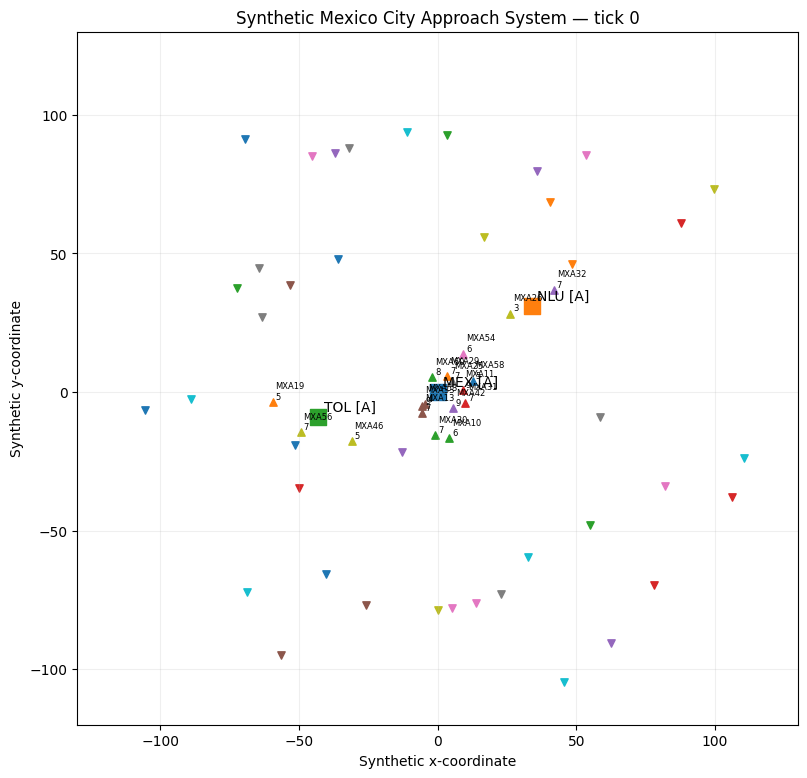

In [ ]:
# Cell 23 — radar-style system view
def plot_airspace(fleet, tick=0):
    fig, ax = plt.subplots(figsize=(10, 9))

    for code, ap in AIRPORTS.items():
        ax.scatter(ap.x, ap.y, s=140, marker="s")
        ax.text(ap.x + 2, ap.y + 2, f"{code} [{ap.runway_mode}]")

    for w in weather:
        if w.active:
            ax.add_patch(plt.Circle((w.x, w.y), w.radius, alpha=0.18))
            ax.text(w.x, w.y, f"{w.name}\n{w.severity:.2f}", ha="center")

    for a in fleet:
        if a.status != "ACTIVE":
            continue
        marker = "v" if a.phase == "ARRIVAL" else "^"
        ax.scatter(a.x, a.y, s=28, marker=marker)

        if dist_ap(a) < 55 or in_weather(a.x, a.y):
            ax.text(a.x + 1, a.y + 1, f"{a.callsign}\n{a.altitude:.0f}", fontsize=6)

    ax.set_title(f"Synthetic Mexico City Approach System — tick {tick}")
    ax.set_xlim(-130, 130)
    ax.set_ylim(-120, 130)
    ax.set_aspect("equal")
    ax.set_xlabel("Synthetic x-coordinate")
    ax.set_ylabel("Synthetic y-coordinate")
    ax.grid(alpha=0.2)
    plt.show()


plot_airspace(aircraft, 0)


## Cell 24 — Layer 14: Running the integrated autonomous experiment

The final code cell stops defining components and runs the system as a whole. Before the experiment begins, it deliberately resets airport state, weather state, random seeds, the sixty-aircraft fleet, telemetry, and the audit log. This makes the cell rerunnable: executing the notebook twice should start from the same synthetic world instead of continuing from aircraft that were already handed off in the previous run.

`USE_CLAUDE` controls whether the experiment is allowed to use the external supervisory reasoner. Even when it is true, Claude is used only if Cell 4 successfully created the client. Otherwise, deterministic fallback remains active. This distinction allows the notebook to demonstrate the full architecture in classrooms or environments where an API key is not available, while still enabling live bounded judgment when credentials exist.

The simulation then advances from tick 1 through `MAX_TICKS`. Each tick calls the complete feedback loop from Cell 22. Periodic status lines and event-triggered lines make important transitions visible without printing every step. After the run, the cell converts history into a telemetry DataFrame, displays the recent state, plots selected time series, displays the final radar map, and summarizes the audit log if proposals were generated.

This integrated run is where the earlier architectural separations become empirically meaningful. World dynamics create new conditions; perception and prediction rebuild the state; congestion analysis and context construction organize evidence; Claude or fallback proposes; the harness validates; execution changes targets; aircraft dynamics alter the environment; contingencies enter from outside; and feedback repeats the sequence. Observability surrounds the entire process.

The important result is not whether a particular run achieves a perfect numerical score. The experiment demonstrates that autonomous behavior can emerge from a governed composition of specialized components. Cell 24 therefore serves as both the execution of the model and the final systems test: every preceding layer must cooperate for the simulation to evolve coherently from start to finish.


Integrated run will use claude-haiku-4-5-20251001 through the bounded supervisory gateway.
{'tick': 25, 'active': 60, 'tower_handoffs': 0, 'enroute_handoffs': 0, 'conflicts': 0, 'weather_active': 0, 'judgment_source': 'NO_SUPERVISORY_CALL', 'events': ''}
{'tick': 50, 'active': 60, 'tower_handoffs': 0, 'enroute_handoffs': 0, 'conflicts': 1, 'weather_active': 0, 'judgment_source': 'NO_SUPERVISORY_CALL', 'events': ''}
{'tick': 60, 'active': 60, 'tower_handoffs': 0, 'enroute_handoffs': 0, 'conflicts': 1, 'weather_active': 1, 'judgment_source': 'CLAUDE', 'events': 'WX1 activated'}
{'tick': 75, 'active': 60, 'tower_handoffs': 0, 'enroute_handoffs': 0, 'conflicts': 4, 'weather_active': 1, 'judgment_source': 'CLAUDE', 'events': ''}
{'tick': 100, 'active': 59, 'tower_handoffs': 1, 'enroute_handoffs': 0, 'conflicts': 2, 'weather_active': 1, 'judgment_source': 'CLAUDE', 'events': ''}
{'tick': 105, 'active': 59, 'tower_handoffs': 1, 'enroute_handoffs': 0, 'conflicts': 2, 'weather_active': 2, 'judg

,tick,active,tower_handoffs,enroute_handoffs,conflicts,weather_active,judgment_source,events
285,286,0,42,18,0,1,NO_SUPERVISORY_CALL,
286,287,0,42,18,0,1,NO_SUPERVISORY_CALL,
287,288,0,42,18,0,1,DETERMINISTIC_FALLBACK,
288,289,0,42,18,0,1,NO_SUPERVISORY_CALL,
289,290,0,42,18,0,1,NO_SUPERVISORY_CALL,
290,291,0,42,18,0,1,NO_SUPERVISORY_CALL,
291,292,0,42,18,0,1,NO_SUPERVISORY_CALL,
292,293,0,42,18,0,1,NO_SUPERVISORY_CALL,
293,294,0,42,18,0,1,NO_SUPERVISORY_CALL,
294,295,0,42,18,0,1,NO_SUPERVISORY_CALL,


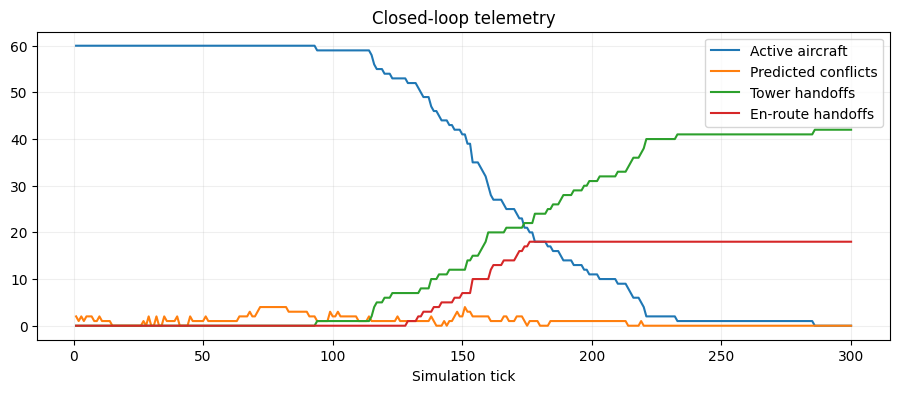

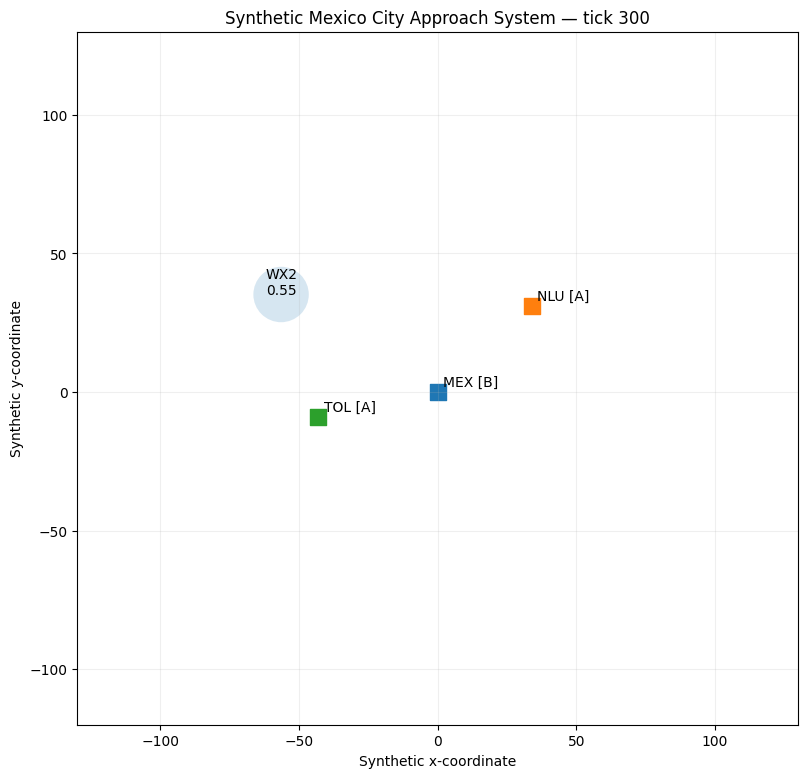

Governance audit summary:


,tick,source,accepted,validator_reason
421,174,CLAUDE,True,accepted
422,175,CLAUDE,True,accepted
423,175,CLAUDE,True,accepted
424,175,CLAUDE,True,accepted
425,180,CLAUDE,True,accepted
426,180,CLAUDE,True,accepted
427,180,CLAUDE,True,accepted
428,192,CLAUDE,True,accepted
429,192,CLAUDE,True,accepted
430,192,CLAUDE,True,accepted


In [ ]:
# Cell 24 — integrated experiment
USE_CLAUDE = True

# Clean reset so this cell can be rerun without carrying state from a previous experiment.
reset_airports()
reset_weather()
random.seed(SEED)
np.random.seed(SEED)
aircraft = reset_fleet()
history.clear()
audit_log.clear()

if USE_CLAUDE and CLAUDE_ENABLED:
    print(f"Integrated run will use {MODEL} through the bounded supervisory gateway.")
elif USE_CLAUDE and not CLAUDE_ENABLED:
    print("USE_CLAUDE=True, but no Claude client is available; deterministic fallback will be used.")
else:
    print("Claude disabled for this run; deterministic fallback will be used.")

for tick in range(1, MAX_TICKS + 1):
    snapshot = sim_tick(aircraft, tick)
    if tick % 25 == 0 or snapshot["events"]:
        print(snapshot)

telemetry = pd.DataFrame(history)
display(telemetry.tail(15))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(telemetry.tick, telemetry.active, label="Active aircraft")
ax.plot(telemetry.tick, telemetry.conflicts, label="Predicted conflicts")
ax.plot(telemetry.tick, telemetry.tower_handoffs, label="Tower handoffs")
ax.plot(telemetry.tick, telemetry.enroute_handoffs, label="En-route handoffs")
ax.set_title("Closed-loop telemetry")
ax.set_xlabel("Simulation tick")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

plot_airspace(aircraft, MAX_TICKS)

if audit_log:
    audit_df = pd.DataFrame(audit_log)
    print("Governance audit summary:")
    display(audit_df[["tick", "source", "accepted", "validator_reason"]].tail(20))
else:
    print("No supervisory proposals were generated during the run.")


# Cell 25 — Conclusion: From an autonomous agent to a governed autonomous system

The experiment began with a simple question: what changes when the object of autonomous control is no longer one machine but an interacting system? The answer is visible in the architecture we have built. A multi-airport traffic environment cannot be reduced to a single LLM call, a single policy, or a single optimization. It requires a chain of specialized capabilities that repeatedly transform the state of the world into evidence, forecasts, judgment, validated authority, physical action, and new evidence.

The first transformation is from **world to perception**. Airports, aircraft, weather, wind, and infrastructure state exist as simulation objects, but the controller needs an explicit representation of what matters now. Cell 11 creates that state. Prediction then adds time. By projecting motion and identifying possible future interactions, Cell 12 demonstrates why autonomy must reason about what may happen rather than merely classify what is happening. Cell 13 goes further by turning individual aircraft into system-level congestion and sequencing information. This is the moment at which the controlled object clearly becomes the traffic system rather than a collection of unrelated agents.

The next transformation is from **analysis to institutional context**. The notebook does not ask Claude to reconstruct the entire world from raw records. Cell 17 assembles a compact situation packet containing predicted conflicts, airport pressure, weather, runway state, focused aircraft, and the specific candidate actions available to them. Context is therefore engineered rather than accidental. The supervisory model receives a representation created by deterministic layers that already know how to count, project, filter, and structure.

Claude Haiku 4.5 contributes judgment, but the notebook deliberately limits what “judgment” means. The model is asked to choose a small number of interventions from menus generated outside the model. More importantly, the model does not possess execution authority. Cell 16 remains between proposal and action. It verifies that an aircraft exists, that the command is permitted, that its numeric value falls inside the synthetic envelope, that a vector does not probe into active weather, that a state restriction is respected, and that the proposal actually belongs to the current candidate set.

This separation is the central governance lesson of the notebook. **Intelligence and authority are different design problems.** A system may benefit from a powerful reasoner without granting that reasoner unconstrained control. The reasoner can be replaced, upgraded, unavailable, or wrong while the institutional architecture around it continues to enforce limits. The deterministic fallback in Cell 18 makes the same point from another direction: graceful degradation is possible because the autonomous loop is larger than the model connection.

The experiment also demonstrates why execution must be separated from dynamics. An accepted command changes a target; it does not instantaneously rewrite physical reality. Different aircraft respond at different synthetic rates. That delay matters because the next control decision must be based on what actually happened, not on what the previous decision intended to happen. Cell 22 closes this gap by rebuilding the state after execution and dynamics. Autonomy is therefore recursive. The system repeatedly observes the consequences of its own actions and of external events.

Contingencies make that recursion essential. Weather can appear, move, intensify, and dissipate. Wind can alter the airport state. These changes are not errors in the controller; they are changes in the world. The correct response is not to defend the old plan but to reconstruct the situation and decide again. This is the essence of adaptive control and a broader lesson for autonomous institutions: plans are provisional because environments are endogenous, uncertain, and changing.

Finally, the notebook distinguishes autonomy from invisibility. Telemetry, audit records, and the radar-style view give a human observer several windows into system behavior. We can see whether the number of active aircraft declines as handoffs occur, whether conflict counts change, whether Claude or fallback supplied a proposal, and whether the deterministic harness accepted or rejected it. Observability is therefore part of governance, not merely presentation.

The architecture can be summarized in one line:

**Perceive → Predict → Analyze → Construct Context → Judge → Validate → Execute → Observe the Physical Response → Repeat.**

The LLM participates in only one segment of that sequence. The rest of the intelligence resides in structured state, numerical computation, candidate generation, deterministic rules, physical dynamics, triggering logic, memory, and human-facing observability. That is the deeper pedagogical result.

The progression from the earlier single-vehicle experiments to this sixty-aircraft simulation is therefore not merely an increase in scale. It is a change in the nature of the problem. When many agents interact under shared constraints and changing external conditions, the autonomous system begins to resemble an institution: specialized functions observe, forecast, propose, authorize, execute, record, and adapt. The controlled object is no longer the machine. **The controlled object is the system.**
